<a href="https://colab.research.google.com/github/Lingeshkumar24-code/NLP-projects/blob/main/NLP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # Add this line
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
comments = [
    "This product is amazing!",
    "Worst customer service ever.",
    "I love the new design.",
    "Very disappointed with the quality.",
    "Excellent experience.",
    "Not worth the money.",
    "Fast delivery and great packaging.",
    "The app keeps crashing.",
    "Highly recommended!",
    "Terrible support team."
]

df = pd.DataFrame(comments, columns=["Comment"])

print(df)

                               Comment
0             This product is amazing!
1         Worst customer service ever.
2               I love the new design.
3  Very disappointed with the quality.
4                Excellent experience.
5                 Not worth the money.
6   Fast delivery and great packaging.
7              The app keeps crashing.
8                  Highly recommended!
9               Terrible support team.


In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned"] = df["Comment"].apply(clean_text)

print(df)

                               Comment                        Cleaned
0             This product is amazing!                product amazing
1         Worst customer service ever.    worst customer service ever
2               I love the new design.                love new design
3  Very disappointed with the quality.           disappointed quality
4                Excellent experience.           excellent experience
5                 Not worth the money.                    worth money
6   Fast delivery and great packaging.  fast delivery great packaging
7              The app keeps crashing.             app keeps crashing
8                  Highly recommended!             highly recommended
9               Terrible support team.          terrible support team


In [7]:
def sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(sentiment)

print(df)

                               Comment                        Cleaned  \
0             This product is amazing!                product amazing   
1         Worst customer service ever.    worst customer service ever   
2               I love the new design.                love new design   
3  Very disappointed with the quality.           disappointed quality   
4                Excellent experience.           excellent experience   
5                 Not worth the money.                    worth money   
6   Fast delivery and great packaging.  fast delivery great packaging   
7              The app keeps crashing.             app keeps crashing   
8                  Highly recommended!             highly recommended   
9               Terrible support team.          terrible support team   

  Sentiment  
0  Positive  
1  Negative  
2  Positive  
3  Negative  
4  Positive  
5  Positive  
6  Positive  
7   Neutral  
8  Positive  
9  Negative  


In [8]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    6
Negative    3
Neutral     1
Name: count, dtype: int64


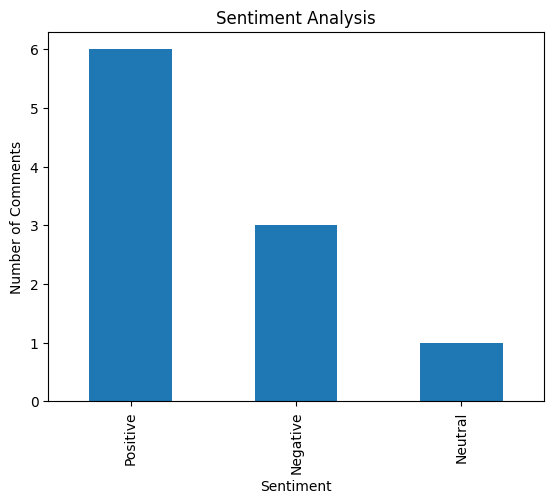

In [9]:
df["Sentiment"].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

In [10]:
text = " ".join(df["Cleaned"])

print(text)

product amazing worst customer service ever love new design disappointed quality excellent experience worth money fast delivery great packaging app keeps crashing highly recommended terrible support team


In [11]:
from collections import Counter

words = text.split()

counter = Counter(words)

print(counter.most_common(10))

[('product', 1), ('amazing', 1), ('worst', 1), ('customer', 1), ('service', 1), ('ever', 1), ('love', 1), ('new', 1), ('design', 1), ('disappointed', 1)]


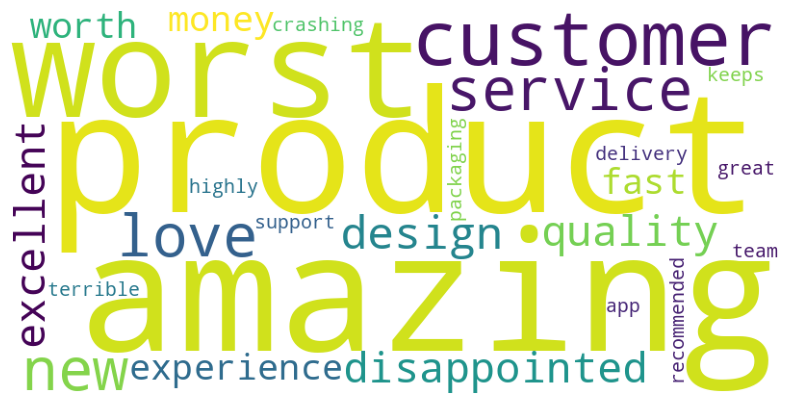

In [12]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()